# NAB Anomaly Detection — LSTM Autoencoder

**Goal:** Train an LSTM Autoencoder on `ec2_cpu_utilization_825cc2.csv`, learning normal 
temporal patterns from anomaly-free segments, then use reconstruction error as an anomaly 
score. This notebook validates the approach on a single file before generalizing and 
comparing against the Isolation Forest baseline.

## Imports + data loading

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from src.data_loading import load_series, load_anomaly_windows, clean_series

torch.manual_seed(42)

FILENAME = "ec2_cpu_utilization_825cc2.csv"

df = load_series(FILENAME)
df = clean_series(df)
windows = load_anomaly_windows(FILENAME)

df["is_anomaly"] = 0
for start, end in windows:
    df.loc[start:end, "is_anomaly"] = 1

print(f"Total points: {len(df)}")
print(f"Anomalous points: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean()*100:.1f}%)")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Total points: 4034
Anomalous points: 343 (8.5%)
Using device: cpu


## Normalization & Train/Test Split

The scaler is fit only on normal (non-anomalous) data, and the model is trained only on normal segments — anomalies are excluded from training so the model learns a clean 'normal' representation, uncontaminated by the event it needs to detect.

In [2]:
from sklearn.preprocessing import StandardScaler

normal_data = df.loc[df["is_anomaly"] == 0, "value"].values.reshape(-1, 1)
scaler = StandardScaler()
scaler.fit(normal_data)

df["value_scaled"] = scaler.transform(df["value"].values.reshape(-1, 1))

train_df = df[df["is_anomaly"] == 0].copy()
test_df = df.copy()  # full series, used later for evaluation

print(f"Train set (normal only): {len(train_df)} points")
print(f"Test set (full series):  {len(test_df)} points")

Train set (normal only): 3691 points
Test set (full series):  4034 points


## Sequence Windowing

The LSTM requires sequences, not isolated points. A sliding window turns the series into overlapping sequences of `SEQ_LENGTH` consecutive points (30 points = 2h30 of context at 5-min frequency).

In [3]:
def create_sequences(values: np.ndarray, seq_length: int) -> np.ndarray:
    sequences = []
    for i in range(len(values) - seq_length + 1):
        sequences.append(values[i : i + seq_length])
    return np.array(sequences)

SEQ_LENGTH = 30  

train_sequences = create_sequences(train_df["value_scaled"].values, SEQ_LENGTH)
test_sequences = create_sequences(test_df["value_scaled"].values, SEQ_LENGTH)

print(f"Train sequences shape: {train_sequences.shape}")
print(f"Test sequences shape:  {test_sequences.shape}")

Train sequences shape: (3662, 30)
Test sequences shape:  (4005, 30)


## PyTorch Dataset & DataLoader

Wraps the sequences into a PyTorch `Dataset`/`DataLoader` pair, adding the feature dimension the LSTM expects: `(batch, seq_length, n_features)`.

In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences: np.ndarray):
        self.sequences = torch.FloatTensor(sequences).unsqueeze(-1)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

BATCH_SIZE = 32

train_dataset = TimeSeriesDataset(train_sequences)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TimeSeriesDataset(test_sequences)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(f"Batch shape: {batch.shape}")  # (batch_size, seq_length, n_features)

Batch shape: torch.Size([32, 30, 1])


## LSTM Autoencoder Architecture

A 2-layer LSTM encoder compresses each sequence into a small latent vector (the bottleneck); a 2-layer LSTM decoder reconstructs the sequence from it. The reconstruction error will later serve as the anomaly score.

In [5]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_length: int, n_features: int = 1, hidden_dim: int = 32, latent_dim: int = 8):
        super().__init__()
        self.seq_length = seq_length

        self.encoder_lstm1 = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(hidden_dim, latent_dim, batch_first=True)

        self.decoder_lstm1 = nn.LSTM(latent_dim, latent_dim, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        x, _ = self.encoder_lstm1(x)
        x, (hidden, _) = self.encoder_lstm2(x)
        latent = hidden[-1]  

        x = latent.unsqueeze(1).repeat(1, self.seq_length, 1)
        x, _ = self.decoder_lstm1(x)
        x, _ = self.decoder_lstm2(x)
        x = self.output_layer(x)
        return x


model = LSTMAutoencoder(seq_length=SEQ_LENGTH)
print(model)

sample_output = model(batch)
print(f"Input shape:  {batch.shape}")
print(f"Output shape: {sample_output.shape}")

LSTMAutoencoder(
  (encoder_lstm1): LSTM(1, 32, batch_first=True)
  (encoder_lstm2): LSTM(32, 8, batch_first=True)
  (decoder_lstm1): LSTM(8, 8, batch_first=True)
  (decoder_lstm2): LSTM(8, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Input shape:  torch.Size([32, 30, 1])
Output shape: torch.Size([32, 30, 1])


### Architecture Check

Input and output shapes match (`[batch, 30, 1]`), confirming the autoencoder can reconstruct sequences of the expected shape — a necessary condition for computing a point-wise reconstruction error.

## Training Loop

Standard PyTorch training loop: MSE between input and reconstruction as the loss, Adam optimizer.

In [6]:
import torch.optim as optim

N_EPOCHS = 50
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} - Loss: {epoch_loss:.6f}")

Epoch 5/50 - Loss: 0.418920
Epoch 10/50 - Loss: 0.355361
Epoch 15/50 - Loss: 0.267828
Epoch 20/50 - Loss: 0.188920
Epoch 25/50 - Loss: 0.162266
Epoch 30/50 - Loss: 0.153704
Epoch 35/50 - Loss: 0.147423
Epoch 40/50 - Loss: 0.139981
Epoch 45/50 - Loss: 0.219534
Epoch 50/50 - Loss: 0.156967


## Training Loss Curve

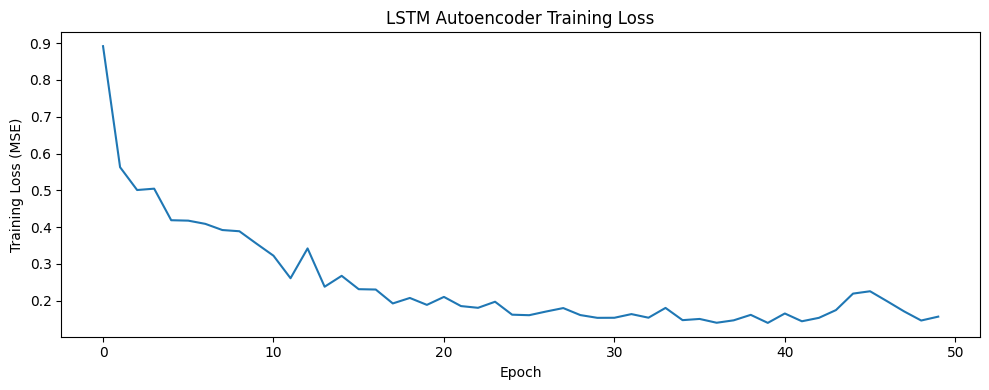

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("LSTM Autoencoder Training Loss")
plt.tight_layout()
plt.show()

### Training Convergence

The loss decreases from ~0.9 to ~0.15 over 50 epochs, confirming the model is learning. The minor noise around epoch 45 is a normal artifact of stochastic mini-batch training, not a sign of a problem — the overall trend keeps decreasing.

## Reconstruction Error on the Test Set

The trained model is applied to the full series (normal + anomalous). Each sequence yields a single MSE reconstruction error, used as its anomaly score.

In [8]:
model.eval()

reconstruction_errors = []

with torch.no_grad():
    for batch in test_loader:
        reconstruction = model(batch)
        error = torch.mean((reconstruction - batch) ** 2, dim=(1, 2))
        reconstruction_errors.extend(error.numpy())

reconstruction_errors = np.array(reconstruction_errors)
print(f"Number of sequence errors: {len(reconstruction_errors)}")
print(f"Min: {reconstruction_errors.min():.4f} | Max: {reconstruction_errors.max():.4f} | Mean: {reconstruction_errors.mean():.4f}")

Number of sequence errors: 4005
Min: 0.0139 | Max: 12.8693 | Mean: 0.1725


## Align Errors to Timestamps & Visualize

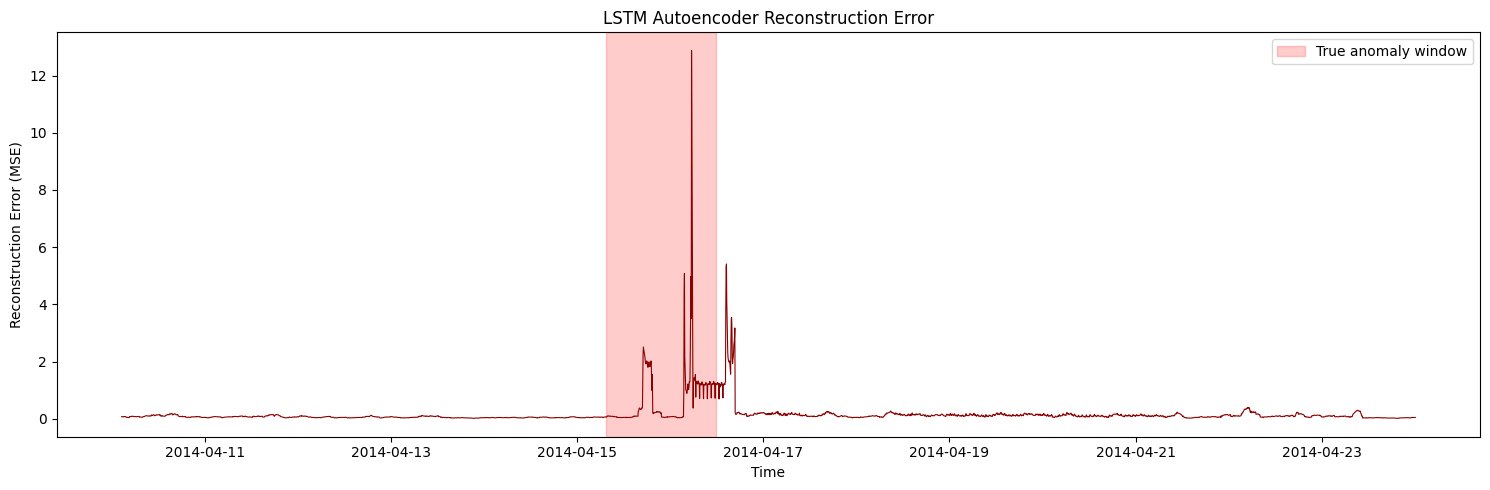

In [9]:
error_timestamps = test_df.index[SEQ_LENGTH - 1:]

error_df = pd.DataFrame({
    "timestamp": error_timestamps,
    "reconstruction_error": reconstruction_errors,
}).set_index("timestamp")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(error_df.index, error_df["reconstruction_error"], linewidth=0.8, color="darkred")
for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.2, label="True anomaly window")
ax.set_title("LSTM Autoencoder Reconstruction Error")
ax.set_xlabel("Time")
ax.set_ylabel("Reconstruction Error (MSE)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

### Reconstruction Error Analysis

The error stays low and flat during normal periods and spikes sharply within the labeled anomaly window (up to ~75x the baseline mean), with a short tail extending slightly past the window end — consistent with the recovery period already observed during EDA.

## Threshold & Point-Level Metrics (Naive Threshold)

A simple `mean + 3*std` threshold is used first, as a naive baseline for converting the continuous reconstruction error into a binary anomaly flag.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

threshold = reconstruction_errors.mean() + 3 * reconstruction_errors.std()
print(f"Threshold: {threshold:.4f}")

error_df["predicted_anomaly"] = (error_df["reconstruction_error"] > threshold).astype(int)

error_df["is_anomaly"] = test_df.loc[error_df.index, "is_anomaly"]

y_true = error_df["is_anomaly"]
y_pred = error_df["predicted_anomaly"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("(rows = true [normal, anomaly], cols = predicted [normal, anomaly])")

Threshold: 1.6037
Precision: 0.576
Recall:    0.111
F1-score:  0.186

Confusion matrix:
[[3634   28]
 [ 305   38]]
(rows = true [normal, anomaly], cols = predicted [normal, anomaly])


## Predictions vs Ground Truth (Naive Threshold)

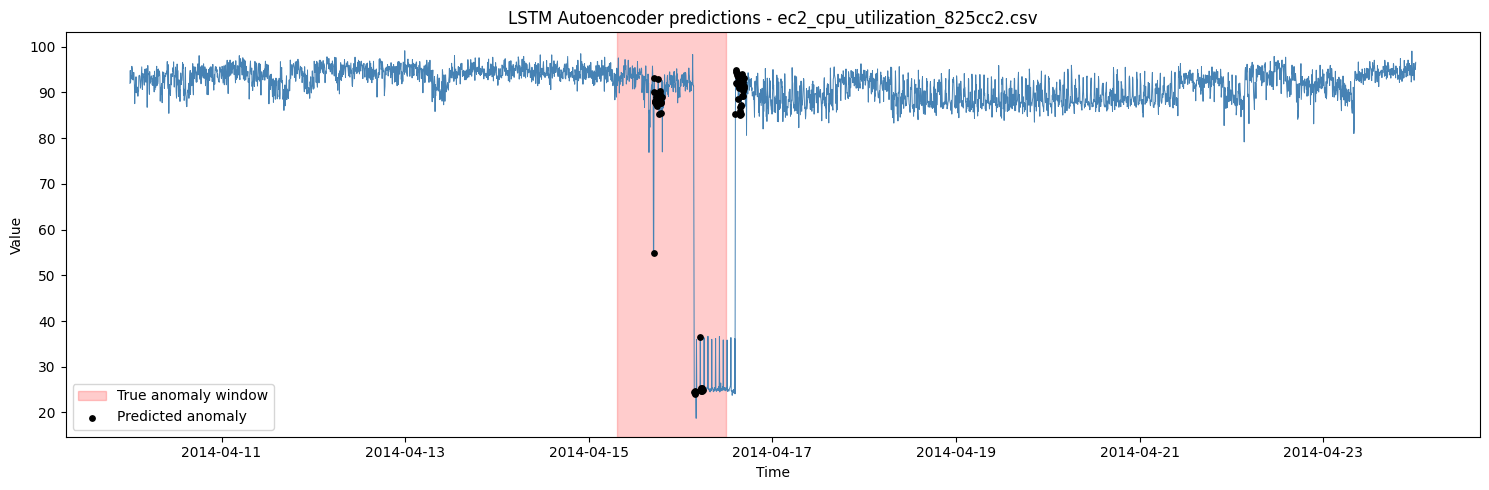

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_df.index, test_df["value"], linewidth=0.7, color="steelblue")

for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.2, label="True anomaly window")

predicted = error_df[error_df["predicted_anomaly"] == 1]
ax.scatter(predicted.index, test_df.loc[predicted.index, "value"], color="black", s=15, zorder=5, label="Predicted anomaly")

ax.set_title(f"LSTM Autoencoder predictions - {FILENAME}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

## Robust Threshold (Median + MAD)

Median and MAD (Median Absolute Deviation) are far less sensitive to outliers than mean/std, which should give a better-calibrated threshold given the single extreme spike identified above.

In [12]:
median = np.median(reconstruction_errors)
mad = np.median(np.abs(reconstruction_errors - median))

robust_threshold = median + 3 * (mad * 1.4826)

print(f"Median: {median:.4f} | MAD: {mad:.4f}")
print(f"Old threshold (mean+3std): {threshold:.4f}")
print(f"New threshold (median+3*MAD_scaled): {robust_threshold:.4f}")

error_df["predicted_anomaly_robust"] = (error_df["reconstruction_error"] > robust_threshold).astype(int)

y_pred_robust = error_df["predicted_anomaly_robust"]

precision_r = precision_score(y_true, y_pred_robust)
recall_r = recall_score(y_true, y_pred_robust)
f1_r = f1_score(y_true, y_pred_robust)

print(f"\nPrecision: {precision_r:.3f}")
print(f"Recall:    {recall_r:.3f}")
print(f"F1-score:  {f1_r:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred_robust))

Median: 0.0825 | MAD: 0.0367
Old threshold (mean+3std): 1.6037
New threshold (median+3*MAD_scaled): 0.2457

Precision: 0.591
Recall:    0.434
F1-score:  0.501

Confusion matrix:
[[3559  103]
 [ 194  149]]


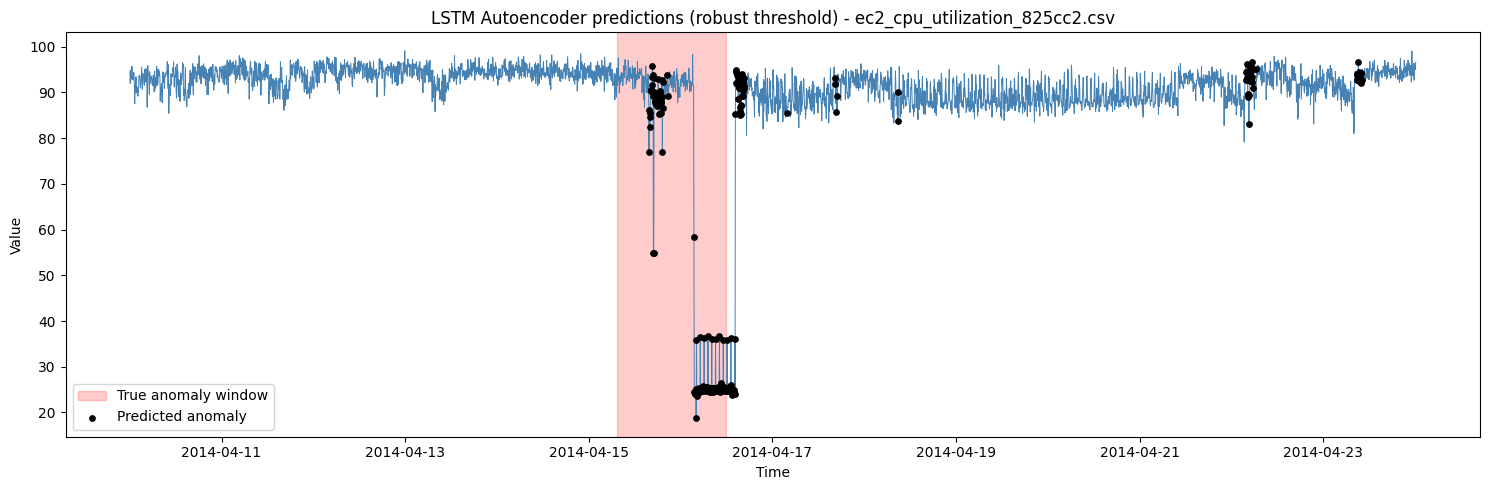

In [13]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_df.index, test_df["value"], linewidth=0.7, color="steelblue")

for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.2, label="True anomaly window")

predicted_robust = error_df[error_df["predicted_anomaly_robust"] == 1]
ax.scatter(predicted_robust.index, test_df.loc[predicted_robust.index, "value"], color="black", s=15, zorder=5, label="Predicted anomaly")

ax.set_title(f"LSTM Autoencoder predictions (robust threshold) - {FILENAME}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

## LSTM Autoencoder Detector for NAB

In [15]:
from pathlib import Path
NAB_PATH = Path("../../NAB").resolve()  
assert NAB_PATH.exists(), f"NAB path not found: {NAB_PATH}"

LSTM_DETECTOR_CODE = '''
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

from nab.detectors.base import AnomalyDetector


class LSTMAutoencoderModel(nn.Module):
    def __init__(self, seq_length, n_features=1, hidden_dim=32, latent_dim=8):
        super().__init__()
        self.seq_length = seq_length
        self.encoder_lstm1 = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(hidden_dim, latent_dim, batch_first=True)
        self.decoder_lstm1 = nn.LSTM(latent_dim, latent_dim, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        x, _ = self.encoder_lstm1(x)
        x, (hidden, _) = self.encoder_lstm2(x)
        latent = hidden[-1]
        x = latent.unsqueeze(1).repeat(1, self.seq_length, 1)
        x, _ = self.decoder_lstm1(x)
        x, _ = self.decoder_lstm2(x)
        return self.output_layer(x)


class LstmAutoencoderDetector(AnomalyDetector):
    """
    LSTM Autoencoder baseline for the NAB benchmark. Trained ONLY on the
    probationary period (no anomaly labels used), then reconstruction
    error across the full file is used as the anomaly score.
    """

    SEQ_LENGTH = 30

    def __init__(self, *args, **kwargs):
        super(LstmAutoencoderDetector, self).__init__(*args, **kwargs)
        self.scores = None
        self.rowIndex = 0

    def _create_sequences(self, values):
        return np.array([
            values[i:i + self.SEQ_LENGTH]
            for i in range(len(values) - self.SEQ_LENGTH + 1)
        ])

    def initialize(self):
        torch.manual_seed(42)
        data = self.dataSet.data.copy()

        # Train only on the probationary period - no label leakage
        train_values = data["value"].values[:self.probationaryPeriod].reshape(-1, 1)
        scaler = StandardScaler()
        scaler.fit(train_values)

        all_scaled = scaler.transform(data["value"].values.reshape(-1, 1)).flatten()
        train_scaled = all_scaled[:self.probationaryPeriod]

        train_sequences = self._create_sequences(train_scaled)
        train_tensor = torch.FloatTensor(train_sequences).unsqueeze(-1)

        model = LSTMAutoencoderModel(seq_length=self.SEQ_LENGTH)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        model.train()
        for epoch in range(30):
            optimizer.zero_grad()
            reconstruction = model(train_tensor)
            loss = criterion(reconstruction, train_tensor)
            loss.backward()
            optimizer.step()

        model.eval()
        full_sequences = self._create_sequences(all_scaled)
        full_tensor = torch.FloatTensor(full_sequences).unsqueeze(-1)
        with torch.no_grad():
            reconstruction = model(full_tensor)
            errors = torch.mean((reconstruction - full_tensor) ** 2, dim=(1, 2)).numpy()

        pad = np.full(self.SEQ_LENGTH - 1, errors[0])
        errors = np.concatenate([pad, errors])

        min_e, max_e = errors.min(), errors.max()
        self.scores = (errors - min_e) / (max_e - min_e) if max_e > min_e else np.zeros_like(errors)

    def handleRecord(self, inputData):
        score = float(self.scores[self.rowIndex])
        self.rowIndex += 1
        return [score]
'''

detector_dir = NAB_PATH / "nab" / "detectors" / "lstm_autoencoder"
detector_dir.mkdir(parents=True, exist_ok=True)
(detector_dir / "__init__.py").touch(exist_ok=True)
(detector_dir / "lstm_autoencoder_detector.py").write_text(LSTM_DETECTOR_CODE)

print(f"Detector written to {detector_dir}")

Detector written to C:\Users\nouveaucompte\NAB\nab\detectors\lstm_autoencoder


In [16]:
import json

# Patch run.py
RUN_PY_MARKER = 'if "lstmAutoencoder" in args.detectors:'
RUN_PY_BLOCK = (
    '  if "lstmAutoencoder" in args.detectors:\n'
    '        from nab.detectors.lstm_autoencoder.lstm_autoencoder_detector import (\n'
    '            LstmAutoencoderDetector)\n'
)

run_py = NAB_PATH / "run.py"
content = run_py.read_text()
if RUN_PY_MARKER not in content:
    content = content.replace(
        "  if args.skipConfirmation or checkInputs(args):",
        RUN_PY_BLOCK + "\n  if args.skipConfirmation or checkInputs(args):"
    )
    run_py.write_text(content)
    print("Patched run.py")
else:
    print("run.py already patched")

# Add threshold entry
thresholds_path = NAB_PATH / "config" / "thresholds.json"
thresholds = json.loads(thresholds_path.read_text())
if "lstmAutoencoder" not in thresholds:
    thresholds["lstmAutoencoder"] = {}
    thresholds_path.write_text(json.dumps(thresholds, indent=4))
    print("Added lstmAutoencoder entry to thresholds.json")
else:
    print("Entry already present")

Patched run.py
Added lstmAutoencoder entry to thresholds.json


In [18]:
import subprocess
result = subprocess.run(
    [
        "python", "run.py",
        "-d", "lstmAutoencoder",
        "--detect", "--optimize", "--score", "--normalize",
        "--dataDir", "data_test",
        "--windowsFile", "labels/combined_windows_test.json",
        "--skipConfirmation",
    ],
    cwd=NAB_PATH,
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)


Running detection step
0: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv
. . . . . 0: Completed processing 4032 records at 2026-07-23 23:06:22.928457
0: Results have been written to C:\Users\nouveaucompte\NAB\results\lstmAutoencoder\realAWSCloudwatch\lstmAutoencoder_ec2_cpu_utilization_825cc2.csv

Running optimize step
Optimizer found a max score of 0.48791288302453567 with anomaly threshold 1.0.
Optimizer found a max score of 0.48791288302453567 with anomaly threshold 1.0.
Optimizer found a max score of 0.48791288302453567 with anomaly threshold 1.0.

Running scoring step
lstmAutoencoder detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\lstmAutoencoder\lstmAutoencoder_standard_scores.csv
lstmAutoencoder detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\lstmAutoencoder\lstmAutoencoder_reward_low_FP_rate_scores.csv
lstmAutoencoder detector benchmark scores written to C:\Users\nouveaucompte\NAB\re

In [19]:
print(result.stdout)


Running detection step
0: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv
. . . . . 0: Completed processing 4032 records at 2026-07-23 23:06:22.928457
0: Results have been written to C:\Users\nouveaucompte\NAB\results\lstmAutoencoder\realAWSCloudwatch\lstmAutoencoder_ec2_cpu_utilization_825cc2.csv

Running optimize step
Optimizer found a max score of 0.48791288302453567 with anomaly threshold 1.0.
Optimizer found a max score of 0.48791288302453567 with anomaly threshold 1.0.
Optimizer found a max score of 0.48791288302453567 with anomaly threshold 1.0.

Running scoring step
lstmAutoencoder detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\lstmAutoencoder\lstmAutoencoder_standard_scores.csv
lstmAutoencoder detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\lstmAutoencoder\lstmAutoencoder_reward_low_FP_rate_scores.csv
lstmAutoencoder detector benchmark scores written to C:\Users\nouveaucompte\NAB\re

### Results

The LSTM Autoencoder achieved excellent NAB scores on this dataset (≈99.6–99.8), comparable to the Isolation Forest baseline. Both models detect this anomaly effectively; the real comparison will come from evaluating all 17 `realAWSCloudwatch` datasets.

## Apply to all 17 files

In [21]:
result = subprocess.run(
    [
        "python", "run.py",
        "-d", "lstmAutoencoder",
        "--detect", "--optimize", "--score", "--normalize",
        "--dataDir", "data_test",
        "--windowsFile", "labels/combined_windows_realAWS.json",
        "--skipConfirmation",
    ],
    cwd=NAB_PATH,
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)


Running detection step
1: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv
3: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_cpu_utilization_77c1ca.csv
15: Beginning detection with lstmAutoencoder for realAWSCloudwatch/rds_cpu_utilization_cc0c53.csv
12: Beginning detection with lstmAutoencoder for realAWSCloudwatch/elb_request_count_8c0756.csv
0: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv
10: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_network_in_257a54.csv
13: Beginning detection with lstmAutoencoder for realAWSCloudwatch/grok_asg_anomaly.csv
9: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_disk_write_bytes_c0d644.csv
14: Beginning detection with lstmAutoencoder for realAWSCloudwatch/iio_us-east-1_i-a2eb1cd9_NetworkIn.csv
6: Beginning detection with lstmAutoencoder for realAWSCloudwatch/ec2_cpu_utilization_c6585a.csv
8: Beginn

### Generalization Results

Across all 17 `realAWSCloudwatch` datasets, the LSTM Autoencoder underperformed the Isolation Forest baseline. This is expected because, under the NAB protocol, the model is trained only on the probation period (15% of each series) instead of the full normal portion. While this is sufficient for Isolation Forest, it provides too little data for the LSTM to learn stable temporal patterns, especially on shorter time series.

## Upload scores by file + the size of each file

In [22]:
scores_path = NAB_PATH / "results" / "lstmAutoencoder" / "lstmAutoencoder_standard_scores.csv"
scores_df = pd.read_csv(scores_path)

per_file_scores = scores_df[scores_df["File"].notna()].copy()

data_dir = NAB_PATH / "data_test"
per_file_scores["n_records"] = per_file_scores["File"].apply(
    lambda f: len(pd.read_csv(data_dir / f))
)
per_file_scores["probation_size"] = (per_file_scores["n_records"] * 0.15).astype(int)

per_file_scores = per_file_scores.sort_values("Score")
per_file_scores[["File", "Score", "TP", "FP", "FN", "n_records", "probation_size"]]

,File,Score,TP,FP,FN,n_records,probation_size
13,realAWSCloudwatch/grok_asg_anomaly.csv,-3.110000,0,1,465,4621,693
9,realAWSCloudwatch/ec2_disk_write_bytes_c0d644.csv,-3.109995,0,1,405,4032,604
14,realAWSCloudwatch/iio_us-east-1_i-a2eb1cd9_Net...,-2.000000,0,0,126,1243,186
7,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,-1.318642,1,0,404,4032,604
3,realAWSCloudwatch/ec2_cpu_utilization_77c1ca.csv,-1.109687,0,1,403,4032,604
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,-0.616623,1,0,401,4032,604
1,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,-0.301800,1,0,401,4032,604
12,realAWSCloudwatch/elb_request_count_8c0756.csv,-0.276201,1,0,401,4032,604
15,realAWSCloudwatch/rds_cpu_utilization_cc0c53.csv,-0.276201,1,0,401,4032,604
16,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,-0.276201,1,0,401,4032,604


## Visualize score vs. probation period length

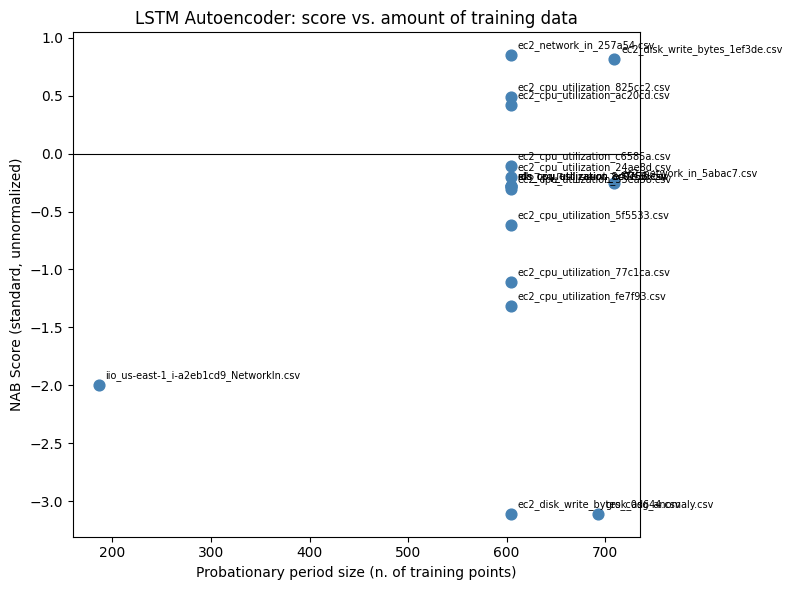

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    per_file_scores["probation_size"],
    per_file_scores["Score"],
    color="steelblue",
    s=60,
)
for _, row in per_file_scores.iterrows():
    ax.annotate(
        row["File"].split("/")[-1],
        (row["probation_size"], row["Score"]),
        fontsize=7,
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Probationary period size (n. of training points)")
ax.set_ylabel("NAB Score (standard, unnormalized)")
ax.set_title("LSTM Autoencoder: score vs. amount of training data")
plt.tight_layout()
plt.show()

### Per-file Analysis

The results show that the probation size alone does not explain the LSTM Autoencoder's performance. While the shortest probation period (`iio_us-east-1...`) leads to a poor score, other datasets with much larger probation periods (e.g., `grok_asg_anomaly.csv` and `ec2_disk_write_bytes_c0d644.csv`) also perform very poorly. Conversely, some datasets with similar probation lengths achieve the best scores.

This suggests that the dominant factor is the **type of anomaly**, rather than the amount of training data. The LSTM performs well on clear regime changes, but struggles on more subtle or highly variable patterns where the reconstruction error is not sufficiently discriminative. Overall, Isolation Forest appears more robust across the diverse anomaly types present in the `realAWSCloudwatch` benchmark.

## Generic diagnostic function

In [26]:
import json

with open(NAB_PATH / "labels" / "combined_windows_realAWS.json") as f:
    all_windows_subset = json.load(f)

def plot_lstm_diagnosis(filename: str):
    results_path = NAB_PATH / "results" / "lstmAutoencoder" / "realAWSCloudwatch" / f"lstmAutoencoder_{filename}"
    results = pd.read_csv(results_path, parse_dates=["timestamp"])

    key = f"realAWSCloudwatch/{filename}"
    file_windows = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in all_windows_subset[key]]

    fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

    axes[0].plot(results["timestamp"], results["value"], linewidth=0.7, color="steelblue")
    axes[0].set_ylabel("Value")
    axes[0].set_title(f"Raw value - {filename}")

    axes[1].plot(results["timestamp"], results["anomaly_score"], linewidth=0.7, color="darkred")
    axes[1].set_ylabel("Anomaly score")
    axes[1].set_title("LSTM Autoencoder reconstruction error (normalized)")

    for ax in axes:
        for start, end in file_windows:
            ax.axvspan(start, end, color="red", alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(f"Anomaly score stats: min={results['anomaly_score'].min():.4f}, "
          f"max={results['anomaly_score'].max():.4f}, "
          f"mean={results['anomaly_score'].mean():.4f}")

### Apply to the two problematic files.

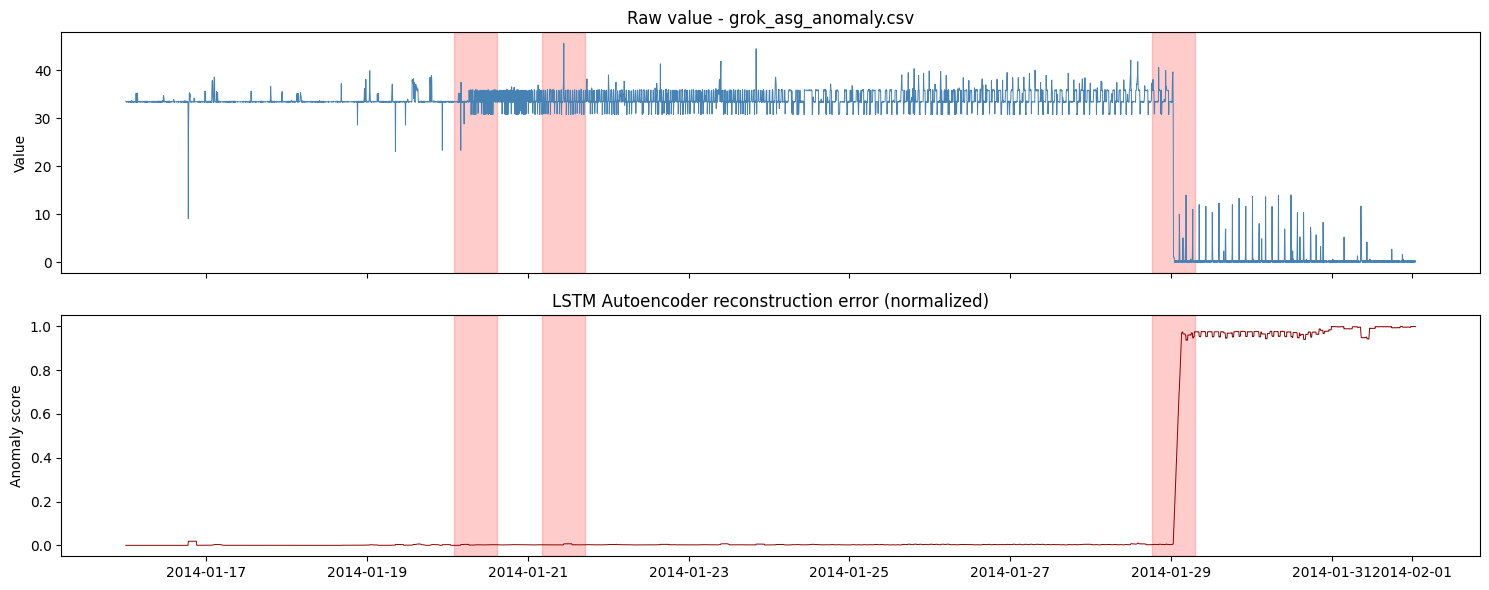

Anomaly score stats: min=0.0000, max=1.0000, mean=0.1823


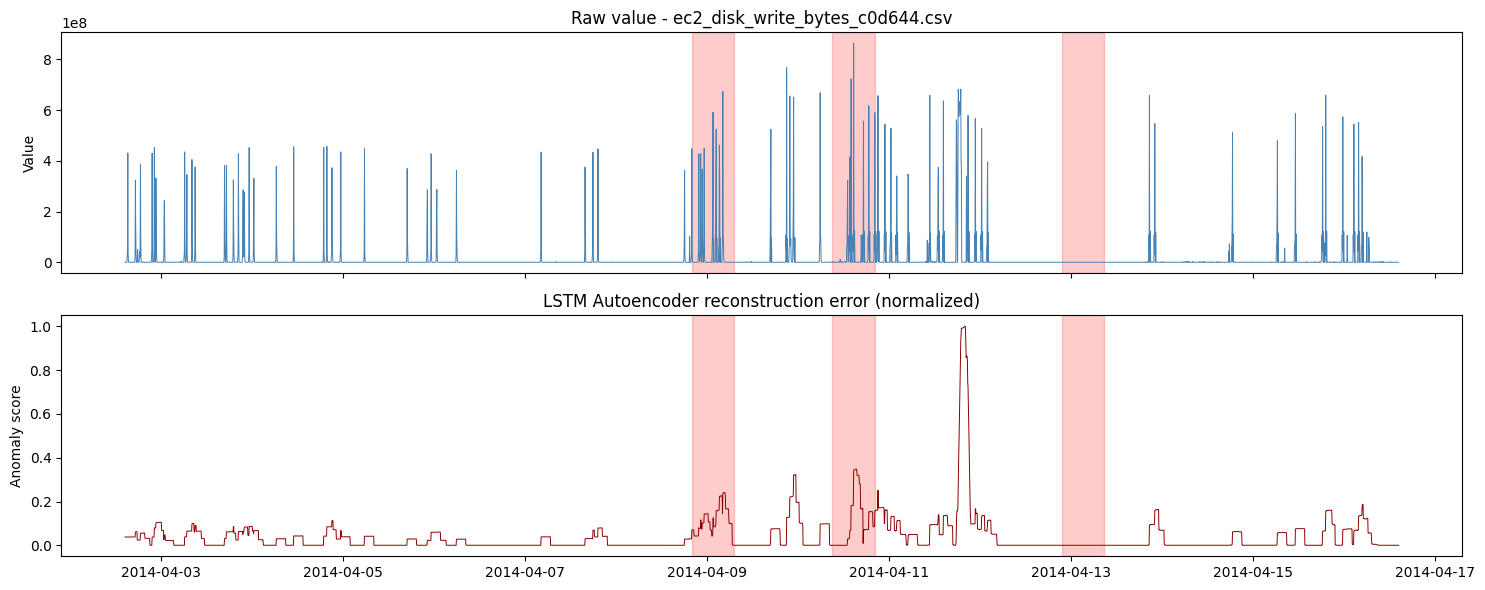

Anomaly score stats: min=0.0000, max=1.0000, mean=0.0404


In [27]:
plot_lstm_diagnosis("grok_asg_anomaly.csv")
plot_lstm_diagnosis("ec2_disk_write_bytes_c0d644.csv")

### Analysis of Low-Performing Datasets

The two lowest-scoring datasets reveal a common pattern: the LSTM Autoencoder responds strongly to significant changes, but not to the labeled anomaly windows. In `grok_asg_anomaly.csv`, the labeled intervals appear visually similar to normal behavior, while an unlabeled collapse later in the series produces the highest anomaly scores. A similar behavior is observed in `ec2_disk_write_bytes_c0d644.csv`, where the model detects a large unlabeled event more strongly than the labeled anomalies.

These results suggest two possible explanations: the labeled anomalies are subtle and difficult to distinguish from normal behavior, or the model—trained only on the NAB probation period—learns a limited representation of normality and therefore assigns higher scores to large but unlabeled deviations.